In [1]:
!pip install -q 'git+https://github.com/facebookresearch/segment-anything.git'

  Preparing metadata (setup.py) ... done


In [2]:
!pip install -q jupyter_bbox_widget roboflow dataclasses-json supervision==0.23.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.5/151.5 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 81.5 MB/s eta 0:00:00


In [3]:
import os
from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/esameM"
os.chdir(path)
HOME = os.getcwd()
print(HOME)

Mounted at /content/drive
/content/drive/MyDrive/esameM


In [4]:

import torch
import os
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
import cv2
import supervision as sv
import numpy as np
from pathlib import Path

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_TYPE = "vit_h"
CHECKPOINT_PATH = os.path.join(f"{HOME}/model/sam_vit_h_4b8939.pth")

default_box_prompt = {'x': 50, 'y': 180, 'width': 540, 'height': 290, 'label': ''}



sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH).to(device=DEVICE)
box = np.array([
    default_box_prompt['x'],
    default_box_prompt['y'],
    default_box_prompt['x'] + default_box_prompt['width'],
    default_box_prompt['y'] + default_box_prompt['height']
])
mask_predictor = SamPredictor(sam)


In [5]:
import numpy as np

def calculate_iou(mask1, mask2):
    """Calculates IoU between two binary masks."""
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    if union == 0:
        return 0.0
    return intersection / union
def dice_coefficient(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    total_pixels = mask1.sum() + mask2.sum()
    dice = (2.0 * intersection) / total_pixels if total_pixels > 0 else 1.0
    return dice

In [12]:

def apply_mask_to_image(image, mask):
    """
    Apply a binary mask to an image, retaining only the masked regions and making the background white.

    Parameters:
    - image: A numpy array representing the original image.
    - mask: A numpy array representing the binary mask.

    Returns:
    - A numpy array representing the masked image with a white background.
    """
    # Ensure the mask is binary
    binary_mask = (mask > 0).astype(np.uint8) * 255

    # Apply the mask to each channel of the image
    masked_image = cv2.bitwise_and(image, image, mask=binary_mask)

    # Create a white background image
    white_background = np.ones_like(image, dtype=np.uint8) * 255

    # Create an inverted mask for the background
    inverted_binary_mask = cv2.bitwise_not(binary_mask)

    # Apply the inverted mask to the white background
    background = cv2.bitwise_and(white_background, white_background, mask=inverted_binary_mask)

    # Combine the masked image with the white background
    final_image = cv2.add(masked_image, background)

    return final_image


def processImageAndCrop(mask_predictor,box,inputImagePath,maskToCompareEntryPath,outputImagePath):
	image_bgr = cv2.imread(inputImagePath,cv2.IMREAD_GRAYSCALE)
	mask_bgr = cv2.imread(maskToCompareEntryPath,cv2.IMREAD_GRAYSCALE)
	mask_orig = np.uint8(mask_bgr)
	image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_GRAY2RGB) #cv2.COLOR_BGR2RGB)
	mask_predictor.set_image(image_rgb)
	masks, scores, logits = mask_predictor.predict(
    box=box,
    multimask_output=True
	)
	detections = sv.Detections(   xyxy=sv.mask_to_xyxy(masks=masks),    mask=masks)
	detections = detections[detections.area == np.max(detections.area)]
	best_mask = masks[np.argmax(scores)]
	#best_mask = detections.mask[0]
	best_mask_bin = np.uint8(best_mask)
	iou=calculate_iou(best_mask_bin,mask_orig)
	dsc=dice_coefficient(best_mask_bin,mask_orig)
	print("dsc="+str(dsc))
	print("iou="+str(iou))
	sv.plot_images_grid(
		images=masks,
		grid_size=(1, 3),
		size=(16, 4)
	)
	sv.plot_images_grid(
		images=[image_bgr,mask_orig,best_mask],
		grid_size=(1, 3),
		size=(16, 4)
	)



	cropped_image = apply_mask_to_image(image_rgb, np.array(best_mask))
	cv2.imwrite(outputImagePath,cv2.cvtColor(cropped_image, cv2.COLOR_RGB2BGR))

/content/drive/MyDrive/esameM/dataset/origForTrainingUnet/imageTest/sick23.jpg
/content/drive/MyDrive/esameM/dataset/origForTrainingUnet/maskOrigTest/sick23.png
dsc=0.0006973276900292589
iou=0.042839021259036235


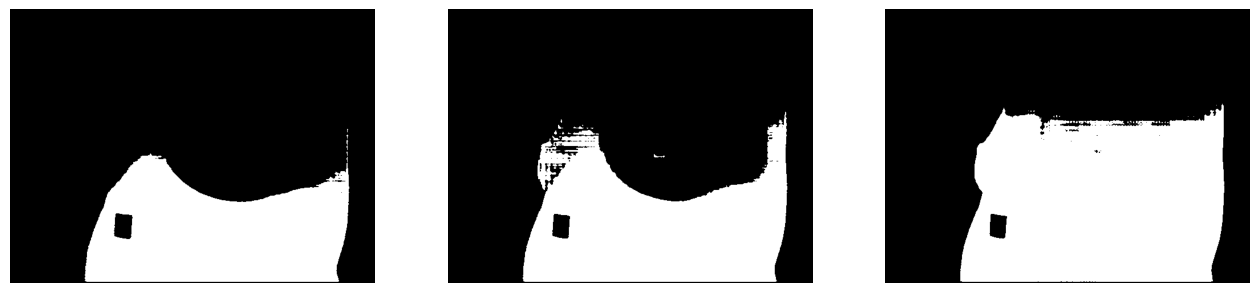

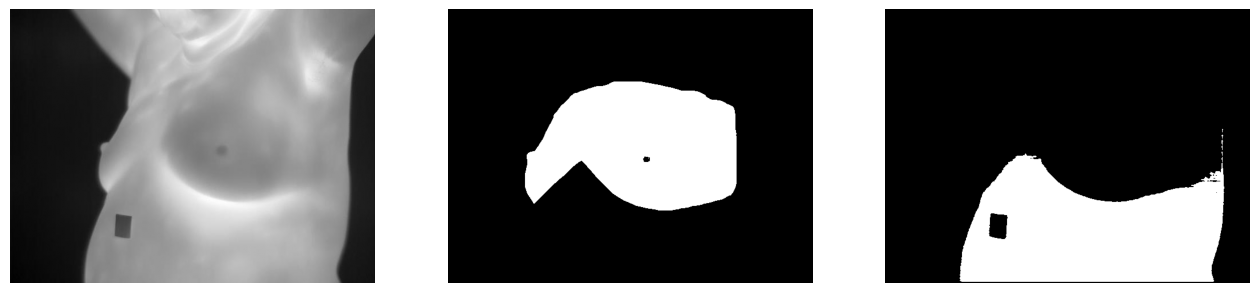

In [13]:

directoryInput = f'{HOME}/dataset/origForTrainingUnet/imageTest/'
directoryInputMask = f'{HOME}/dataset/origForTrainingUnet/maskOrigTest/'
directoryOutput = f'{HOME}/dataset/segmentedSAM/'
for entry in os.scandir(directoryInput):
	if entry.is_file():  # check if it's a file
		print(entry.path)
		outputfilepath=directoryOutput+entry.name

		maskToCompareEntryPath=directoryInputMask+Path(entry.name).stem+".png"
		print(maskToCompareEntryPath)
		processImageAndCrop(mask_predictor,box,entry.path,maskToCompareEntryPath,outputfilepath)
		break